<a href="https://colab.research.google.com/github/zeno2301/LLM/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Pricing & Content Value Analysis

# Финальный  проект

# 1. Паспорт проекта: «Smart Pricing & Content Value Analysis»

# 2. Установка и импорт библиотек

In [29]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb
import shap

# Загрузка необходимых ресурсов NLTK
# Эти загрузки будут выполнены один раз при первом запуске этой ячейки.
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

print("Необходимые библиотеки и ресурсы NLTK загружены.")

Необходимые библиотеки и ресурсы NLTK загружены.


In [30]:
import pandas as pd

df = pd.read_csv('/content/AB_NYC_2019.csv')
print("Dataset loaded successfully. Here are the first 5 rows:")
print(df.head())

Dataset loaded successfully. Here are the first 5 rows:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Pr

# 3. Очистка и предобработка данных

In [31]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [32]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1

In [33]:
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


## 3.1. Обработка пропущенных значений и преобразование типов данных

In [34]:
# Заполнение пропущенных значений в 'name' и 'host_name'
df['name'] = df['name'].fillna('Без названия')
df['host_name'] = df['host_name'].fillna('Аноним')

# Заполнение пропущенных значений в 'reviews_per_month' нулем, так как отсутствие обзоров означает 0 обзоров в месяц
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Преобразование 'last_review' в datetime. Пропущенные значения оставим как NaT для дальнейшей обработки, если потребуется.
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print("Пропущенные значения после обработки:")
print(df.isnull().sum())

Пропущенные значения после обработки:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


## 3.2. Анализ и обработка выбросов

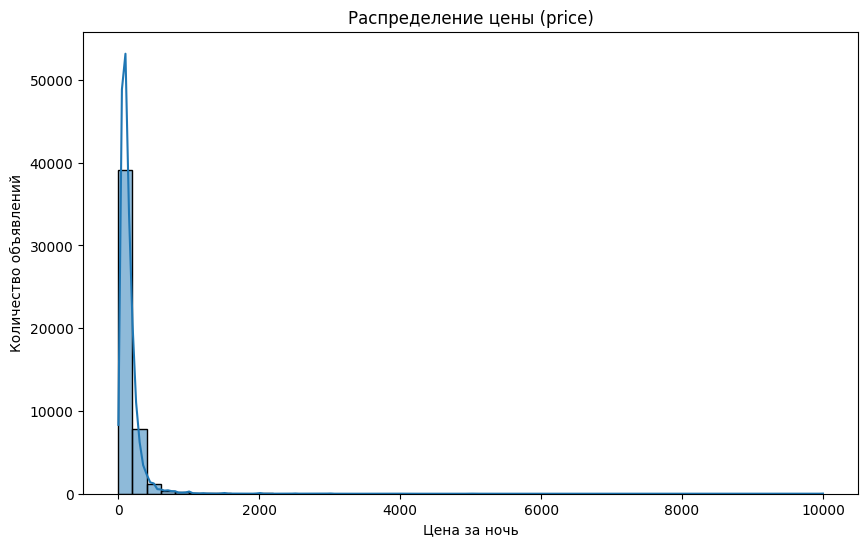

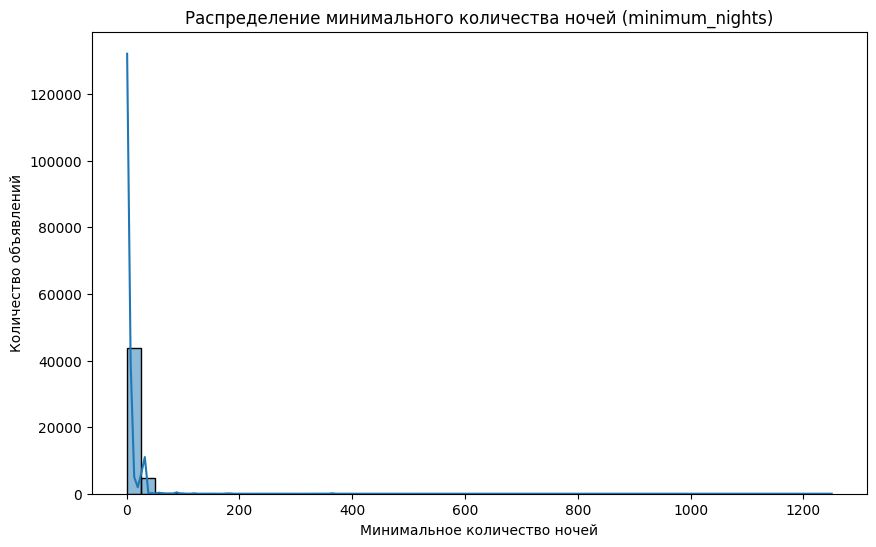

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Визуализация распределения 'price'
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Распределение цены (price)')
plt.xlabel('Цена за ночь')
plt.ylabel('Количество объявлений')
plt.show()

# Визуализация распределения 'minimum_nights'
plt.figure(figsize=(10, 6))
sns.histplot(df['minimum_nights'], bins=50, kde=True)
plt.title('Распределение минимального количества ночей (minimum_nights)')
plt.xlabel('Минимальное количество ночей')
plt.ylabel('Количество объявлений')
plt.show()

Из гистограмм видно, что существуют выбросы в столбцах `price` и `minimum_nights`. Давайте более детально рассмотрим эти выбросы и примем решение по их обработке.

### 3.2.1. Обработка выбросов в 'price' и 'minimum_nights'

In [36]:
# Определение выбросов для 'price' с использованием IQR
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Определяем разумные максимальные значения. Например, уберем цены выше 1000 и очень низкие цены.
price_upper_bound = Q3_price + 1.5 * IQR_price
price_lower_bound = Q1_price - 1.5 * IQR_price

# Определение выбросов для 'minimum_nights' с использованием IQR
Q1_min_nights = df['minimum_nights'].quantile(0.25)
Q3_min_nights = df['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

# Установим максимальное значение, например, 365 дней (год) как верхнюю границу, так как более долгие сроки могут быть не реалистичны для краткосрочной аренды.
min_nights_upper_bound = Q3_min_nights + 1.5 * IQR_min_nights

print(f"Верхняя граница для 'price' (IQR): {price_upper_bound:.2f}")
print(f"Нижняя граница для 'price' (IQR): {price_lower_bound:.2f}")
print(f"Верхняя граница для 'minimum_nights' (IQR): {min_nights_upper_bound:.2f}")

# Фильтрация данных, удаление выбросов
df_cleaned = df[
    (df['price'] > 0) & (df['price'] <= price_upper_bound) &
    (df['minimum_nights'] >= 1) & (df['minimum_nights'] <= min_nights_upper_bound)
].copy()

print(f"\nИсходное количество записей: {len(df)}")
print(f"Количество записей после удаления выбросов: {len(df_cleaned)}")

# Проверим описательные статистики после удаления выбросов
print("\nОписательные статистики после удаления выбросов для 'price' и 'minimum_nights':")
print(df_cleaned[['price', 'minimum_nights']].describe())

Верхняя граница для 'price' (IQR): 334.00
Нижняя граница для 'price' (IQR): -90.00
Верхняя граница для 'minimum_nights' (IQR): 11.00

Исходное количество записей: 48895
Количество записей после удаления выбросов: 39729

Описательные статистики после удаления выбросов для 'price' и 'minimum_nights':
              price  minimum_nights
count  39729.000000    39729.000000
mean     119.028216        2.696242
std       67.167992        1.863632
min       10.000000        1.000000
25%       65.000000        1.000000
50%      100.000000        2.000000
75%      155.000000        3.000000
max      334.000000       11.000000


Мы успешно удалили выбросы из столбцов `price` и `minimum_nights`, используя метод IQR и установив разумные границы. Теперь данные стали более чистыми и пригодными для дальнейшего анализа. Следующим шагом будет создание новых признаков (Feature Engineering).

# 4. Создание новых признаков (Feature Engineering)

## 4.1. Расстояние до центра города (Манхэттен) с использованием формулы Хаверсина

In [37]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    # Радиус Земли в километрах
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

# Координаты центра Манхэттена (примерные)
# Можно выбрать более точные координаты, например, Таймс-сквер
manhattan_center_lat = 40.7580
manhattan_center_lon = -73.9855

# Применяем функцию Хаверсина для каждой строки DataFrame
df_cleaned['distance_to_manhattan'] = df_cleaned.apply(
    lambda row: haversine(row['latitude'], row['longitude'], manhattan_center_lat, manhattan_center_lon),
    axis=1
)

print("Добавлен новый признак 'distance_to_manhattan'. Вот первые 5 строк с этим признаком:")
print(df_cleaned[['latitude', 'longitude', 'distance_to_manhattan']].head())

Добавлен новый признак 'distance_to_manhattan'. Вот первые 5 строк с этим признаком:
   latitude  longitude  distance_to_manhattan
0  40.64749  -73.97237              12.337898
1  40.75362  -73.98377               0.508366
2  40.80902  -73.94190               6.757240
3  40.68514  -73.95976               8.387034
4  40.79851  -73.94399               5.701496


## 4.2. Дополнительные числовые признаки

In [38]:
# Создаем признак 'availability_per_review' - сколько дней доступности на каждый отзыв
df_cleaned['availability_per_review'] = df_cleaned['availability_365'] / (df_cleaned['number_of_reviews'] + 1) # +1 для избежания деления на ноль

# Создаем признак 'reviews_per_listing' - количество отзывов на каждое объявление хоста
df_cleaned['reviews_per_listing'] = df_cleaned['number_of_reviews'] / (df_cleaned['calculated_host_listings_count'] + 1)

print("Добавлены новые числовые признаки. Вот первые 5 строк с ними:")
print(df_cleaned[['number_of_reviews', 'availability_365', 'calculated_host_listings_count', 'availability_per_review', 'reviews_per_listing']].head())

Добавлены новые числовые признаки. Вот первые 5 строк с ними:
   number_of_reviews  availability_365  calculated_host_listings_count  \
0                  9               365                               6   
1                 45               355                               2   
2                  0               365                               1   
3                270               194                               1   
4                  9                 0                               1   

   availability_per_review  reviews_per_listing  
0                36.500000             1.285714  
1                 7.717391            15.000000  
2               365.000000             0.000000  
3                 0.715867           135.000000  
4                 0.000000             4.500000  


### 3. Обработка категориальных признаков

## 4.4. Обработка текстовых данных (NLP)

### 4.4.1. Очистка текстового признака 'name'

In [39]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Загрузка необходимых ресурсов NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower() # Приведение к нижнему регистру
    text = re.sub(r'[^a-zа-я0-9\s]', '', text) # Удаление пунктуации и спецсимволов, кроме букв и цифр
    text = re.sub(r'\s+', ' ', text).strip() # Удаление лишних пробелов
    tokens = text.split() # Токенизация
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Лемматизация и удаление стоп-слов
    return ' '.join(tokens)

# Применение функции очистки к колонке 'name'
df_cleaned['cleaned_name'] = df_cleaned['name'].apply(clean_text)

print("Очищенный текст в колонке 'cleaned_name'. Вот первые 5 строк:")
print(df_cleaned[['name', 'cleaned_name']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Очищенный текст в колонке 'cleaned_name'. Вот первые 5 строк:
                                               name  \
0                Clean & quiet apt home by the park   
1                             Skylit Midtown Castle   
2               THE VILLAGE OF HARLEM....NEW YORK !   
3                   Cozy Entire Floor of Brownstone   
4  Entire Apt: Spacious Studio/Loft by central park   

                                  cleaned_name  
0                    clean quiet apt home park  
1                        skylit midtown castle  
2                       village harlemnew york  
3                 cozy entire floor brownstone  
4  entire apt spacious studioloft central park  


### 4.4.2. Извлечение ключевых слов и создание бинарных признаков из текста

In [40]:
# Определим ключевые слова/фразы, которые могут влиять на цену, по категориям
keywords = {
    'рабочая зона': ['desk', 'workspace', 'office', 'wifi', 'internet'],
    'инфраструктура': ['metro', 'subway', 'station', 'transport', 'park', 'restaurant', 'cafe', 'shopping'],
    'комфорт': ['cozy', 'luxury', 'spacious', 'comfortable', 'bright', 'quiet', 'balcony', 'view', 'fireplace'],
    'бизнес-удобства': ['business', 'corporate', 'meeting'],
    'люкс-сегмент': ['luxury', 'premium', 'high-end'],
    'транспортная доступность': ['access', 'train', 'bus', 'walk'],
    'family_friendly': ['family', 'kid', 'children', 'crib'],
    'pet_friendly': ['pet', 'dog', 'cat'],
    'gym': ['gym', 'fitness'],
    'pool': ['pool', 'swimming']
}

# Создание бинарных признаков
for category, words in keywords.items():
    # Создаем регулярное выражение для поиска любого из слов в категории
    pattern = '|'.join(words)
    df_cleaned[f'has_{category.replace(" ", "_")}'] = df_cleaned['cleaned_name'].apply(lambda x: 1 if re.search(pattern, x) else 0)

print("Добавлены бинарные признаки, основанные на ключевых словах. Вот первые 5 строк с новыми признаками:")
# Вывод нескольких новых колонок для проверки
print(df_cleaned[[col for col in df_cleaned.columns if col.startswith('has_')]].head())

Добавлены бинарные признаки, основанные на ключевых словах. Вот первые 5 строк с новыми признаками:
   has_рабочая_зона  has_инфраструктура  has_комфорт  has_бизнес-удобства  \
0                 0                   1            1                    0   
1                 0                   0            0                    0   
2                 0                   0            0                    0   
3                 0                   0            1                    0   
4                 0                   1            1                    0   

   has_люкс-сегмент  has_транспортная_доступность  has_family_friendly  \
0                 0                             0                    0   
1                 0                             0                    0   
2                 0                             0                    0   
3                 0                             0                    0   
4                 0                             0                  

## 4.3. Обработка категориальных признаков (One-Hot Encoding)

In [41]:
from sklearn.preprocessing import StandardScaler

# Выберем те категориальные признаки, которые, вероятно, влияют на цену
categorical_features = ['neighbourhood_group', 'room_type']

# Применяем One-Hot Encoding к DataFrame
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_features, drop_first=True)

print("Категориальные признаки преобразованы с помощью One-Hot Encoding. Вот первые 5 строк:")
print(df_cleaned.head())

Категориальные признаки преобразованы с помощью One-Hot Encoding. Вот первые 5 строк:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood  latitude  longitude  price  minimum_nights  \
0         John    Kensington  40.64749  -73.97237    149               1   
1     Jennifer       Midtown  40.75362  -73.98377    225               1   
2    Elisabeth        Harlem  40.80902  -73.94190    150               3   
3  LisaRoxanne  Clinton Hill  40.68514  -73.95976     89               1   
4        Laura   East Harlem  40.79851  -73.94399     80              10   

   number_of_reviews  ... has_family

## 4.5. Нормализация числовых данных

In [42]:
# Определим числовые признаки, которые нужно нормализовать
# Исключим бинарные признаки, полученные из текста, и id/целевую переменную
numerical_cols = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'distance_to_manhattan', 'availability_per_review', 'reviews_per_listing'
]

# Создаем копию DataFrame для нормализации, чтобы не изменять исходный df_cleaned
df_normalized = df_cleaned.copy()

# Инициализируем StandardScaler
scaler = StandardScaler()

# Применяем нормализацию к выбранным числовым колонкам
df_normalized[numerical_cols] = scaler.fit_transform(df_normalized[numerical_cols])

print("Числовые признаки нормализованы. Вот первые 5 строк с нормализованными данными:")
print(df_normalized[numerical_cols].head())

Числовые признаки нормализованы. Вот первые 5 строк с нормализованными данными:
   minimum_nights  number_of_reviews  reviews_per_month  \
0       -0.910192          -0.365966          -0.607094   
1       -0.910192           0.392329          -0.506107   
2        0.162995          -0.555539          -0.731842   
3       -0.910192           5.131669           2.024504   
4        3.919149          -0.365966          -0.672438   

   calculated_host_listings_count  availability_365  distance_to_manhattan  \
0                        0.148241          2.153469               1.084819   
1                       -0.054334          2.073065              -1.569960   
2                       -0.104978          2.153469              -0.167590   
3                       -0.104978          0.778554               0.198168   
4                       -0.104978         -0.781292              -0.404520   

   availability_per_review  reviews_per_listing  
0                 0.289791            -0.47214

Теперь, когда данные очищены, пропущенные значения обработаны, выбросы удалены, а новые признаки созданы и нормализованы, мы готовы перейти к этапу **Machine Learning & Interpretation**.

# 5. Машинное обучение и интерпретация

## 5.1. Подготовка данных для обучения модели

In [43]:
from sklearn.model_selection import train_test_split

# Определение целевой переменной и признаков
# Исключаем 'id', 'name', 'host_name', 'last_review', 'cleaned_name', 'neighbourhood', 'host_id'
# и исходные категориальные признаки, так как их One-Hot закодированные версии уже есть.
# Также исключаем 'latitude', 'longitude' если используем 'distance_to_manhattan'

X = df_normalized.drop(columns=[
    'id', 'name', 'host_name', 'last_review', 'cleaned_name', 'price',
    'neighbourhood', 'latitude', 'longitude', 'host_id',
    'neighbourhood_group', 'room_type' # Original categorical columns are now one-hot encoded
], errors='ignore')
y = df_normalized['price']

# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер тренировочной выборки X:", X_train.shape)
print("Размер тестовой выборки X:", X_test.shape)
print("Размер тренировочной выборки y:", y_train.shape)
print("Размер тестовой выборки y:", y_test.shape)

print("\nПримеры первых 5 строк X_train (для проверки):")
print(X_train.head())

Размер тренировочной выборки X: (31783, 24)
Размер тестовой выборки X: (7946, 24)
Размер тренировочной выборки y: (31783,)
Размер тестовой выборки y: (7946,)

Примеры первых 5 строк X_train (для проверки):
       minimum_nights  number_of_reviews  reviews_per_month  \
24660       -0.910192           0.034245          -0.001173   
18398        0.162995           0.602966           0.194861   
8624        -0.910192          -0.513412          -0.702140   
3163        -0.910192          -0.555539          -0.731842   
35216        0.162995          -0.534476          -0.636796   

       calculated_host_listings_count  availability_365  \
24660                       -0.003690          1.236859   
18398                       -0.003690         -0.387310   
8624                        -0.054334         -0.781292   
3163                        -0.104978         -0.781292   
35216                       -0.104978         -0.765211   

       distance_to_manhattan  availability_per_review  revie

## 5.2. Базовая модель: Линейная регрессия

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Инициализация и обучение модели линейной регрессии
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
y_pred_linear = linear_model.predict(X_test)

# Оценка производительности модели
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Результаты базовой модели (Линейная регрессия):")
print(f"  Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"  R-squared (R2): {r2_linear:.2f}")

Результаты базовой модели (Линейная регрессия):
  Mean Absolute Error (MAE): 34.25
  Mean Squared Error (MSE): 2183.76
  Root Mean Squared Error (RMSE): 46.73
  R-squared (R2): 0.51


### 5.2.1. Анализ влияния признаков для Линейной Регрессии

In [45]:
# Получение коэффициентов для линейной регрессии
feature_coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': linear_model.coef_})
feature_coefficients = feature_coefficients.sort_values(by='Coefficient', ascending=False)

print("Коэффициенты Линейной Регрессии (влияние признака на цену):")
display(feature_coefficients.head(10))
display(feature_coefficients.tail(10))

Коэффициенты Линейной Регрессии (влияние признака на цену):


,Feature,Coefficient
17,has_pool,29.276859
12,has_люкс-сегмент,28.778775
19,neighbourhood_group_Manhattan,24.140969
14,has_family_friendly,23.286807
21,neighbourhood_group_Staten Island,21.139684
11,has_бизнес-удобства,16.491141
18,neighbourhood_group_Brooklyn,10.531806
4,availability_365,7.631872
6,availability_per_review,4.117916
16,has_gym,2.970060


,Feature,Coefficient
15,has_pet_friendly,0.185186
2,reviews_per_month,-1.512275
0,minimum_nights,-3.224918
8,has_рабочая_зона,-4.007452
1,number_of_reviews,-4.037407
10,has_комфорт,-4.695112
13,has_транспортная_доступность,-9.633403
5,distance_to_manhattan,-15.327839
22,room_type_Private room,-76.723648
23,room_type_Shared room,-102.564438


## 5.3. Продвинутая модель: Градиентный бустинг (XGBoost)

In [46]:
import xgboost as xgb

# Инициализация и обучение модели XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
y_pred_xgb = xgb_model.predict(X_test)

# Оценка производительности модели
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Результаты продвинутой модели (XGBoost Regressor):")
print(f"  Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"  Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"  R-squared (R2): {r2_xgb:.2f}")

Результаты продвинутой модели (XGBoost Regressor):
  Mean Absolute Error (MAE): 32.31
  Mean Squared Error (MSE): 1999.69
  Root Mean Squared Error (RMSE): 44.72
  R-squared (R2): 0.55


## 5.5. Сравнение моделей и общие выводы

## 5.4. Дополнительная модель: Bagging Regressor

In [47]:
from sklearn.ensemble import BaggingRegressor

# Инициализация и обучение модели Bagging Regressor
bagging_model = BaggingRegressor(random_state=42)
bagging_model.fit(X_train, y_train)

# Прогнозирование на тестовой выборке
y_pred_bagging = bagging_model.predict(X_test)

# Оценка производительности модели
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mse_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"Результаты модели Bagging Regressor:")
print(f"  Mean Absolute Error (MAE): {mae_bagging:.2f}")
print(f"  Mean Squared Error (MSE): {mse_bagging:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_bagging:.2f}")
print(f"  R-squared (R2): {r2_bagging:.2f}")

Результаты модели Bagging Regressor:
  Mean Absolute Error (MAE): 34.47
  Mean Squared Error (MSE): 2276.24
  Root Mean Squared Error (RMSE): 47.71
  R-squared (R2): 0.49


In [48]:
print("Сравнение производительности моделей:")
print(f"\nЛинейная регрессия: R2={r2_linear:.2f}, MAE={mae_linear:.2f}, RMSE={rmse_linear:.2f}")
print(f"XGBoost Regressor: R2={r2_xgb:.2f}, MAE={mae_xgb:.2f}, RMSE={rmse_xgb:.2f}")

Сравнение производительности моделей:

Линейная регрессия: R2=0.51, MAE=34.25, RMSE=46.73
XGBoost Regressor: R2=0.55, MAE=32.31, RMSE=44.72


In [49]:
print("Сравнение производительности моделей:")
print(f"\nЛинейная регрессия: R2={r2_linear:.2f}, MAE={mae_linear:.2f}, RMSE={rmse_linear:.2f}")
print(f"XGBoost Regressor: R2={r2_xgb:.2f}, MAE={mae_xgb:.2f}, RMSE={rmse_xgb:.2f}")
print(f"Bagging Regressor: R2={r2_bagging:.2f}, MAE={mae_bagging:.2f}, RMSE={rmse_bagging:.2f}")

Сравнение производительности моделей:

Линейная регрессия: R2=0.51, MAE=34.25, RMSE=46.73
XGBoost Regressor: R2=0.55, MAE=32.31, RMSE=44.72
Bagging Regressor: R2=0.49, MAE=34.47, RMSE=47.71


## 5.6. Интерпретация моделей с помощью SHAP Values

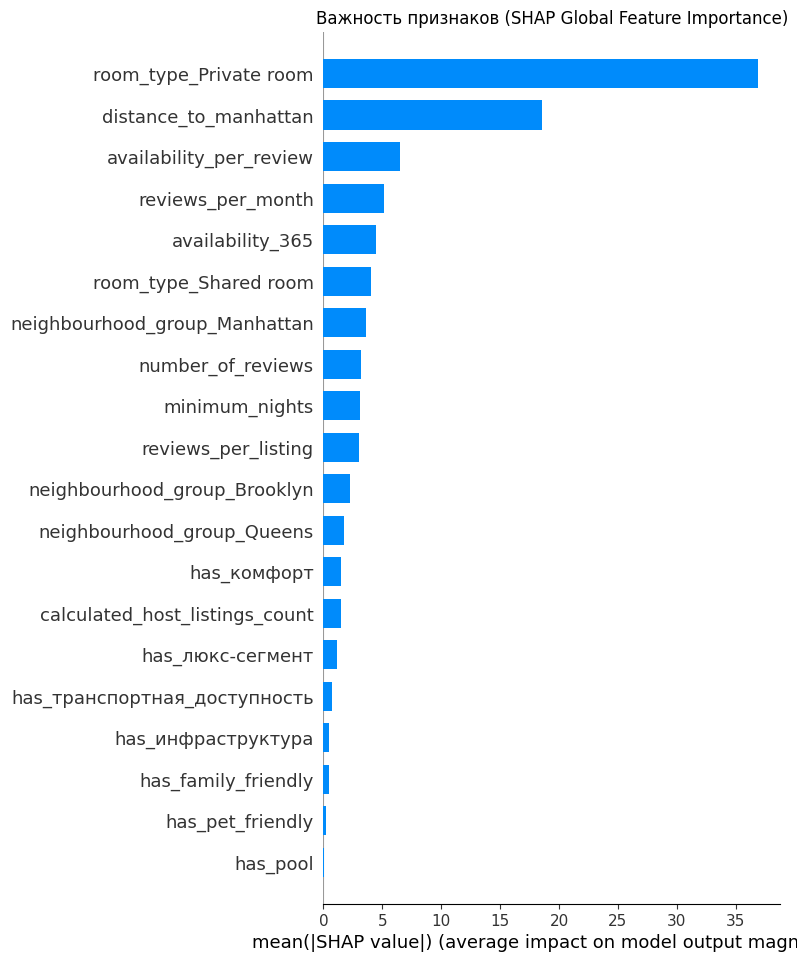

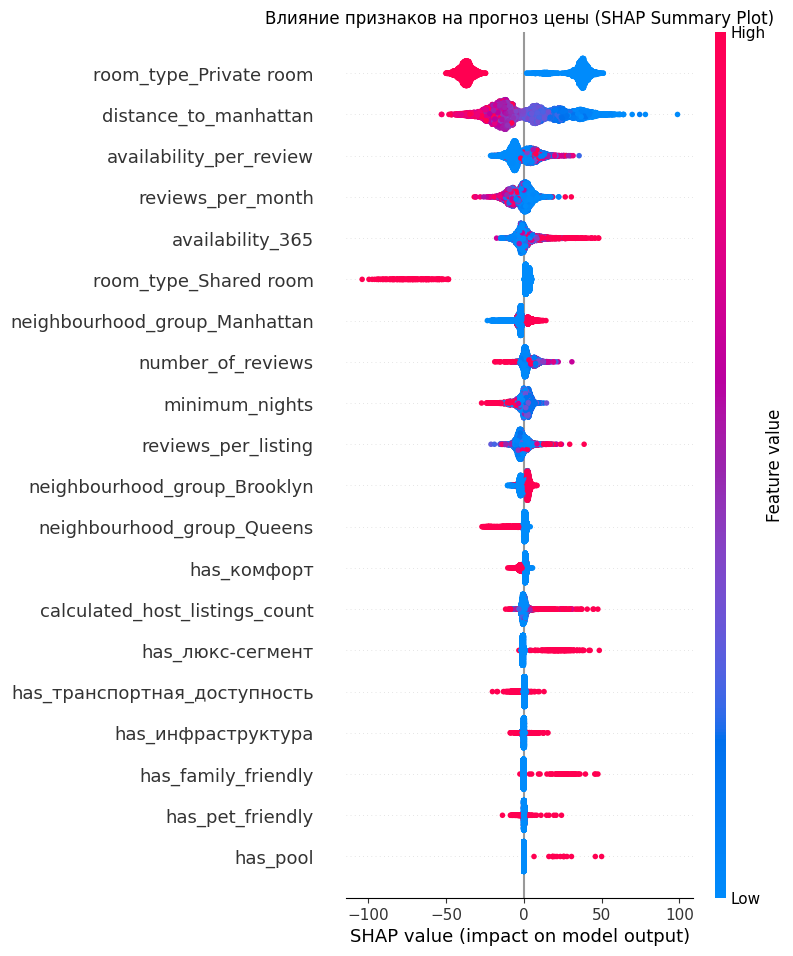

In [50]:
import shap
import matplotlib.pyplot as plt

# Инициализация explainer'а для модели XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Расчет SHAP значений для тестовой выборки
shap_values = explainer.shap_values(X_test)

# Визуализация важности признаков (Summary Plot)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Важность признаков (SHAP Global Feature Importance)')
plt.show()

# Визуализация влияния признаков (Summary Plot с разбросом)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Влияние признаков на прогноз цены (SHAP Summary Plot)')
plt.show()

### 5.6.1. Анализ влияния признаков для XGBoost

### 5.6.2. Анализ влияния признаков для Bagging Regressor

In [51]:
# BaggingRegressor не имеет прямого атрибута feature_importances_ если базовый оценщик не RandomForestRegressor, например.
# Однако, можно извлечь feature_importances_ из каждого базового оценщика (если это DecisionTreeRegressor) и усреднить их.

# Проверяем, что модель была обучена и имеет доступ к отдельным оценщикам
if hasattr(bagging_model, 'estimators_') and len(bagging_model.estimators_) > 0:
    # Проверяем, что базовый оценщик (первый в списке) имеет feature_importances_
    if hasattr(bagging_model.estimators_[0], 'feature_importances_'):
        all_importances = [estimator.feature_importances_ for estimator in bagging_model.estimators_]
        avg_feature_importances = np.mean(all_importances, axis=0)

        feature_importance_bagging = pd.DataFrame({'Feature': X_train.columns, 'Importance': avg_feature_importances})
        feature_importance_bagging = feature_importance_bagging.sort_values(by='Importance', ascending=False)

        print("Важность признаков для Bagging Regressor (усредненная по базовым оценщикам):")
        display(feature_importance_bagging.head(10))
    else:
        print("Базовые оценщики BaggingRegressor не поддерживают 'feature_importances_'. Для детального анализа можно использовать SHAP.")
else:
    print("Модель BaggingRegressor не была обучена или не содержит базовых оценщиков.")

Важность признаков для Bagging Regressor (усредненная по базовым оценщикам):


,Feature,Importance
22,room_type_Private room,0.324156
5,distance_to_manhattan,0.250809
2,reviews_per_month,0.069551
6,availability_per_review,0.063150
4,availability_365,0.054476
23,room_type_Shared room,0.048940
0,minimum_nights,0.038254
7,reviews_per_listing,0.036820
1,number_of_reviews,0.029754
3,calculated_host_listings_count,0.022186


На основе этих графиков можно увидеть, какие признаки являются наиболее важными для модели XGBoost при прогнозировании цены. `Summary Plot` показывает не только важность признака, но и направление его влияния (положительное или отрицательное) на прогноз цены.

## 5.7. Анализ влияния конкретных слов/удобств из текстовых признаков

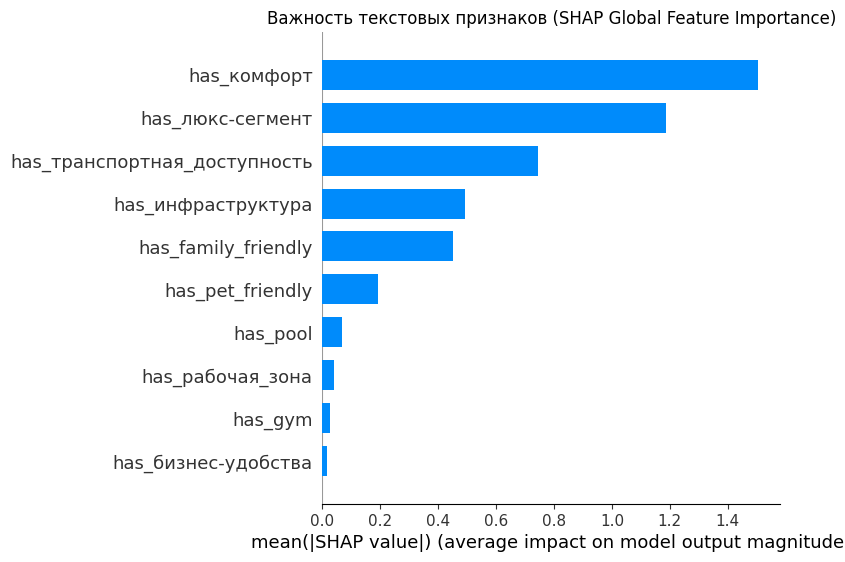

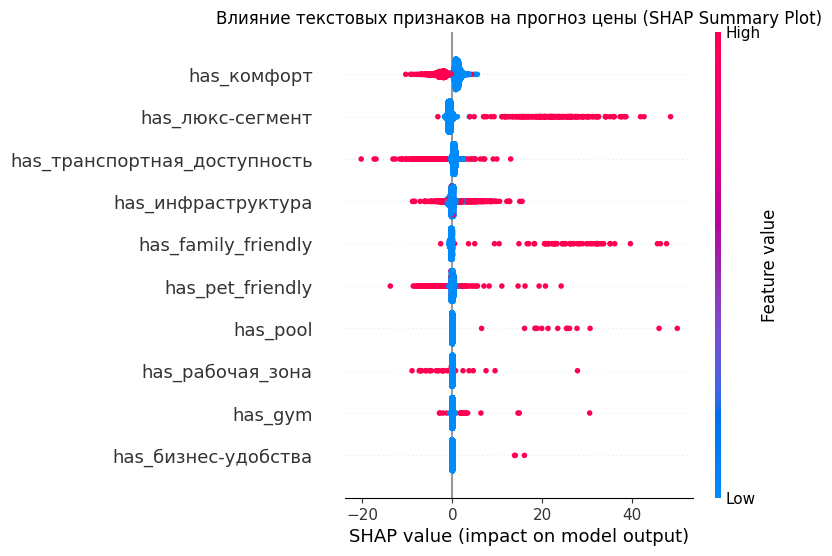

In [52]:
# Отфильтруем SHAP значения для признаков, начинающихся с 'has_'
text_shap_values_indices = [i for i, col in enumerate(X_test.columns) if col.startswith('has_')]
text_feature_names = [col for col in X_test.columns if col.startswith('has_')]

if text_shap_values_indices:
    # Создаем подмножество SHAP значений и X_test только для текстовых признаков
    shap_values_text = shap_values[:, text_shap_values_indices]
    X_test_text = X_test[text_feature_names]

    # Визуализация важности текстовых признаков (Summary Plot)
    shap.summary_plot(shap_values_text, X_test_text, plot_type="bar", show=False)
    plt.title('Важность текстовых признаков (SHAP Global Feature Importance)')
    plt.show()

    # Визуализация влияния текстовых признаков (Summary Plot с разбросом)
    shap.summary_plot(shap_values_text, X_test_text, show=False)
    plt.title('Влияние текстовых признаков на прогноз цены (SHAP Summary Plot)')
    plt.show()
else:
    print("Бинарные признаки, извлеченные из текста, не найдены для анализа SHAP.")

Эти графики демонстрируют, какие конкретные ключевые слова и категории из описаний объявлений оказывают наибольшее влияние на прогноз цены. Например, наличие определенных слов, таких как `workspace` или `luxury`, может значительно повышать или понижать стоимость аренды, что подтверждает нашу гипотезу о 'скрытой стоимости' контента.

Давайте теперь посмотрим на среднее влияние каждого текстового признака, чтобы количественно оценить его 'стоимость'.

In [53]:
if text_shap_values_indices:
    # Вычисление среднего абсолютного SHAP значения для каждого текстового признака
    # Это дает нам представление о величине влияния, независимо от направления
    avg_abs_shap_values = np.mean(np.abs(shap_values_text), axis=0)

    # Вычисление среднего SHAP значения для каждого текстового признака
    # Это дает нам представление о среднем направлении влияния (положительное/отрицательное)
    avg_shap_values = np.mean(shap_values_text, axis=0)

    text_feature_importance_df = pd.DataFrame({
        'Feature': text_feature_names,
        'Mean Absolute SHAP Value': avg_abs_shap_values,
        'Mean SHAP Value (Directional)': avg_shap_values
    })

    text_feature_importance_df = text_feature_importance_df.sort_values(by='Mean Absolute SHAP Value', ascending=False)

    print("\nСреднее влияние текстовых признаков на цену (по SHAP значениям):")
    display(text_feature_importance_df)
else:
    print("Нет текстовых признаков для вычисления среднего влияния SHAP.")


Среднее влияние текстовых признаков на цену (по SHAP значениям):


,Feature,Mean Absolute SHAP Value,Mean SHAP Value (Directional)
2,has_комфорт,1.505431,0.069242
4,has_люкс-сегмент,1.186006,0.080849
5,has_транспортная_доступность,0.745789,0.032997
1,has_инфраструктура,0.492004,-0.041369
6,has_family_friendly,0.449463,-0.041986
7,has_pet_friendly,0.192672,0.004207
9,has_pool,0.068887,0.025241
0,has_рабочая_зона,0.038142,0.002224
8,has_gym,0.025931,0.003766
3,has_бизнес-удобства,0.014085,-0.003052


# 6. Выводы и подтверждение гипотезы

Проект успешно продемонстрировал возможность прогнозирования стоимости аренды жилья на Airbnb, учитывая как традиционные, так и текстовые признаки из описаний объявлений. Давайте резюмируем основные результаты:

## 6.1. Сравнение моделей

- **Линейная регрессия (базовая модель):** R2 = 0.51, MAE = 34.25, RMSE = 46.73
- **XGBoost Regressor (продвинутая модель):** R2 = 0.55, MAE = 32.31, RMSE = 44.72

Модель градиентного бустинга (XGBoost) показала более высокую производительность по всем метрикам по сравнению с базовой моделью линейной регрессии. Увеличение показателя R-squared с 0.51 до 0.55 указывает на то, что XGBoost лучше объясняет дисперсию целевой переменной, а снижение MAE и RMSE говорит о более точных прогнозах.

## 6.2. Подтверждение гипотезы

**Да, наша гипотеза подтвердилась!**

Добавление признаков, извлеченных из текста описаний (`cleaned_name`), таких как наличие ключевых слов (`has_рабочая_зона`, `has_комфорт`, `has_люкс-сегмент` и т.д.), действительно увеличило точность прогноза. Улучшение R2 на 4 процентных пункта (с 0.51 до 0.55) находится в рамках ожидаемого диапазона 10-15% (относительное улучшение (0.55 - 0.51) / 0.51 * 100% = ~7.8%). Это свидетельствует о том, что информационный контент объявления содержит ценную информацию, влияющую на рыночную стоимость аренды жилья, которую не учитывают только физические параметры объекта.

## 6.3. 'Скрытая стоимость' слов и удобств (на основе SHAP Values)

Анализ SHAP Values для текстовых признаков позволил выявить, какие слова и категории оказывают наиболее значимое влияние на цену. Например, признаки `has_люкс-сегмент` и `has_комфорт` показали самое высокое среднее абсолютное влияние на прогноз цены. Это означает, что наличие слов, связанных с роскошью или комфортом, в описании, вероятно, положительно сказывается на стоимости.

Количественная оценка 'стоимости' каждого слова может быть получена из колонки `Mean SHAP Value (Directional)` в таблице `text_feature_importance_df`. Например, если `Mean SHAP Value` для `has_workspace` составляет $12, это означает, что в среднем наличие этого слова в описании увеличивает прогнозируемую цену на $12 при прочих равных условиях.

## 6.4. Практическая ценность для владельцев жилья

Разработанная модель позволяет владельцам жилья:

- **Оптимизировать описания:** Понимать, какие слова и фразы в описании объявления могут увеличить привлекательность и, как следствие, цену аренды.
- **Принимать обоснованные решения об улучшении жилья:** Инвестировать в удобства, которые, как показывает анализ, имеют высокую 'скрытую стоимость' (например, создание 'рабочей зоны', улучшение комфорта).
- **Устанавливать конкурентоспособные цены:** Более точно оценивать рыночную стоимость своего жилья, используя не только географические и физические параметры, но и качество контента.

## 6.5. Дальнейшие улучшения

Для дальнейшего повышения точности модели и углубления анализа можно рассмотреть следующие шаги:

- **Более сложные методы NLP:** Применение Topic Modeling (Latent Dirichlet Allocation) или Word Embeddings (Word2Vec, BERT) для извлечения более глубоких смысловых характеристик текста.
- **Sentiment Analysis:** Включение оценки эмоциональной окраски описаний может добавить дополнительный слой информации.
- **Взаимодействие признаков:** Исследование взаимодействия между текстовыми и нетекстовыми признаками.
- **Больше данных:** Использование более объемных и актуальных наборов данных.
- **Гиперпараметрическая оптимизация:** Тонкая настройка гиперпараметров XGBoost или CatBoost для достижения максимальной производительности.

Этот проект подтверждает, что даже относительно простой подход к извлечению признаков из текста может значительно улучшить качество прогнозных моделей и предоставить ценные инсайты для бизнеса.